# Notebook 1 — EDA & Preprocessing
Loads the raw dataset, explores distributions and key relationships, engineers interaction features, assigns cognitive risk labels, builds the preprocessing pipeline, and saves everything ready for modelling.

In [2]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.append('..')

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from config import RAW_DATA, PROC_DATA, MODELS_DIR, REPORTS_DIR, RANDOM_STATE

sns.set_theme(style='whitegrid', palette='muted')
print("Libraries loaded.")

Libraries loaded.
Libraries loaded.


## 1. Load Raw Data

In [3]:
df = pl.read_csv(RAW_DATA)
print(f"Shape : {df.shape}")
print(f"Columns: {df.columns}")
df.head()

Shape : (80000, 13)
Columns: ['User_ID', 'Age', 'Gender', 'Sleep_Duration', 'Stress_Level', 'Diet_Type', 'Daily_Screen_Time', 'Exercise_Frequency', 'Caffeine_Intake', 'Reaction_Time', 'Memory_Test_Score', 'Cognitive_Score', 'AI_Predicted_Score']


User_ID,Age,Gender,Sleep_Duration,Stress_Level,Diet_Type,Daily_Screen_Time,Exercise_Frequency,Caffeine_Intake,Reaction_Time,Memory_Test_Score,Cognitive_Score,AI_Predicted_Score
str,i64,str,f64,i64,str,f64,str,i64,f64,i64,f64,f64
"""U1""",57,"""Female""",6.5,3,"""Non-Vegetarian""",6.5,"""Medium""",41,583.33,65,36.71,39.77
"""U2""",39,"""Female""",7.6,9,"""Non-Vegetarian""",10.8,"""High""",214,368.24,58,54.35,57.68
"""U3""",26,"""Male""",8.2,6,"""Vegetarian""",5.7,"""Low""",429,445.21,49,32.57,29.54
"""U4""",32,"""Male""",7.8,9,"""Vegetarian""",8.3,"""Low""",464,286.33,94,70.15,74.59
"""U5""",50,"""Male""",9.7,2,"""Non-Vegetarian""",11.3,"""Medium""",365,237.65,62,87.54,91.78


In [4]:
# Data types and summary statistics
print(df.dtypes)
df.describe()

[String, Int64, String, Float64, Int64, String, Float64, String, Int64, Float64, Int64, Float64, Float64]


statistic,User_ID,Age,Gender,Sleep_Duration,Stress_Level,Diet_Type,Daily_Screen_Time,Exercise_Frequency,Caffeine_Intake,Reaction_Time,Memory_Test_Score,Cognitive_Score,AI_Predicted_Score
str,str,f64,str,f64,f64,str,f64,str,f64,f64,f64,f64,f64
"""count""","""80000""",80000.0,"""80000""",80000.0,80000.0,"""80000""",80000.0,"""80000""",80000.0,80000.0,80000.0,80000.0,80000.0
"""null_count""","""0""",0.0,"""0""",0.0,0.0,"""0""",0.0,"""0""",0.0,0.0,0.0,0.0,0.0
"""mean""",null,38.525525,null,7.0053325,5.4937625,null,6.504646,null,248.988213,399.973579,69.49835,58.172395,58.121357
"""std""",null,12.101876,null,1.734435,2.865308,null,3.167072,null,144.54199,115.369329,17.305659,23.058522,23.119598
"""min""","""U1""",18.0,"""Female""",4.0,1.0,"""Non-Vegetarian""",1.0,"""High""",0.0,200.0,40.0,0.0,0.0
"""25%""",null,28.0,null,5.5,3.0,null,3.8,null,123.0,300.15,55.0,40.91,40.85
"""50%""",null,39.0,null,7.0,5.0,null,6.5,null,249.0,400.36,70.0,58.36,58.36
"""75%""",null,49.0,null,8.5,8.0,null,9.2,null,375.0,499.25,85.0,75.83,75.89
"""max""","""U9999""",59.0,"""Other""",10.0,10.0,"""Vegetarian""",12.0,"""Medium""",499.0,599.99,99.0,100.0,100.0


In [5]:
# Missing values — should be zero for this dataset
print(df.null_count())

shape: (1, 13)
┌─────────┬─────┬────────┬─────────────┬───┬─────────────┬─────────────┬─────────────┬─────────────┐
│ User_ID ┆ Age ┆ Gender ┆ Sleep_Durat ┆ … ┆ Reaction_Ti ┆ Memory_Test ┆ Cognitive_S ┆ AI_Predicte │
│ ---     ┆ --- ┆ ---    ┆ ion         ┆   ┆ me          ┆ _Score      ┆ core        ┆ d_Score     │
│ u32     ┆ u32 ┆ u32    ┆ ---         ┆   ┆ ---         ┆ ---         ┆ ---         ┆ ---         │
│         ┆     ┆        ┆ u32         ┆   ┆ u32         ┆ u32         ┆ u32         ┆ u32         │
╞═════════╪═════╪════════╪═════════════╪═══╪═════════════╪═════════════╪═════════════╪═════════════╡
│ 0       ┆ 0   ┆ 0      ┆ 0           ┆ … ┆ 0           ┆ 0           ┆ 0           ┆ 0           │
└─────────┴─────┴────────┴─────────────┴───┴─────────────┴─────────────┴─────────────┴─────────────┘


## 2. Exploratory Data Analysis

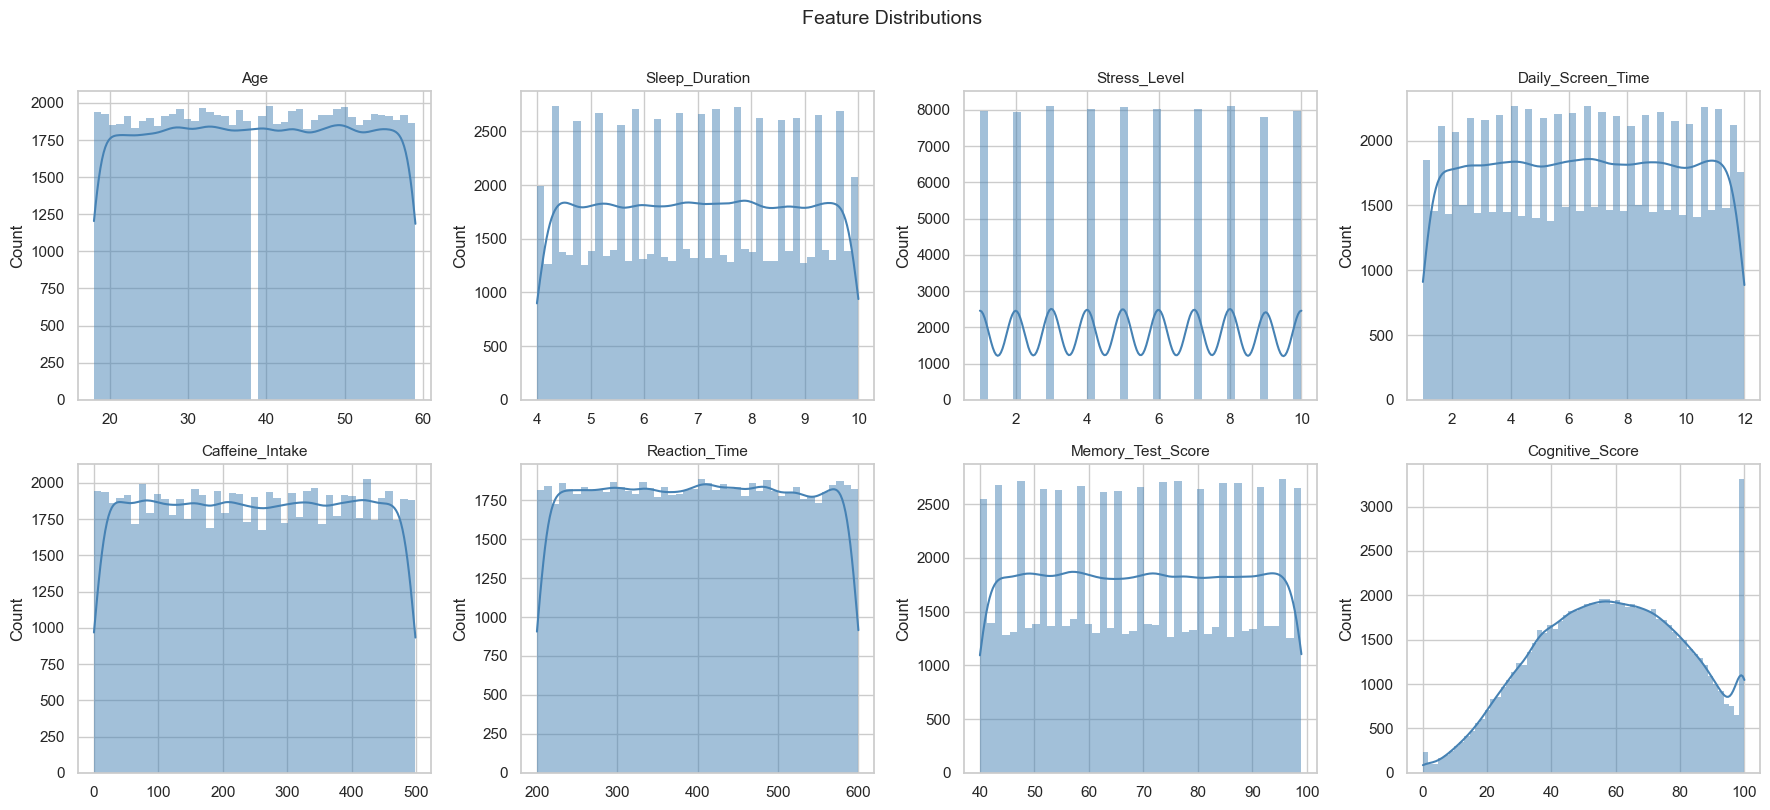

In [6]:
df_pd = df.to_pandas()

NUMERICAL = ['Age', 'Sleep_Duration', 'Stress_Level', 'Daily_Screen_Time',
             'Caffeine_Intake', 'Reaction_Time', 'Memory_Test_Score', 'Cognitive_Score']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Feature Distributions', fontsize=14, y=1.01)
for ax, col in zip(axes.flatten(), NUMERICAL):
    sns.histplot(df_pd[col], kde=True, ax=ax, color='steelblue', edgecolor='none')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

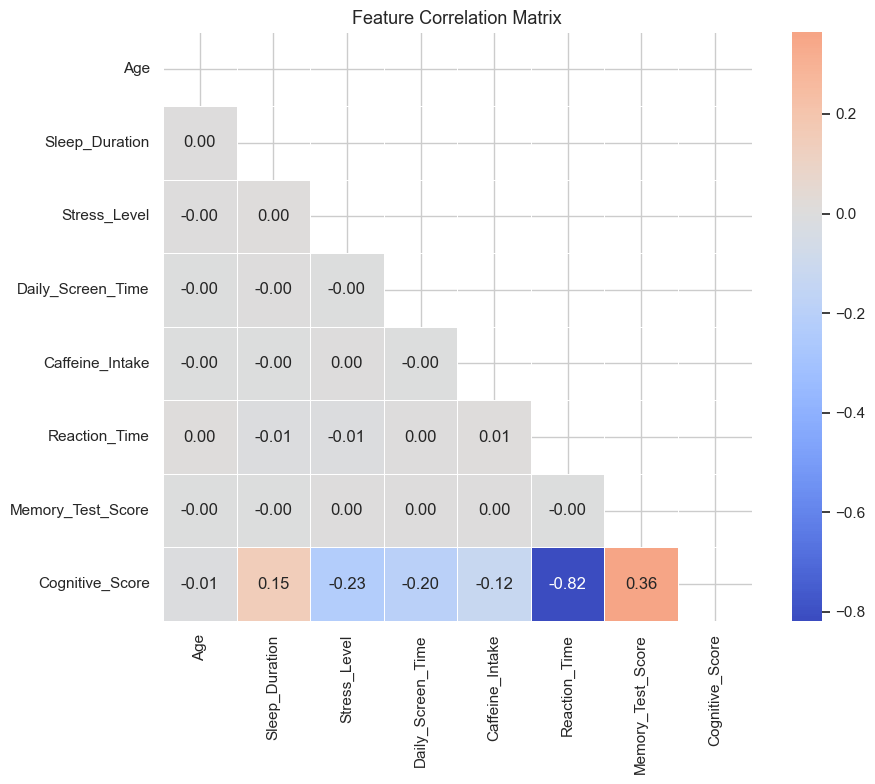

In [7]:
# Correlation heatmap — lower triangle only for readability
plt.figure(figsize=(10, 8))
corr = df_pd[NUMERICAL].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

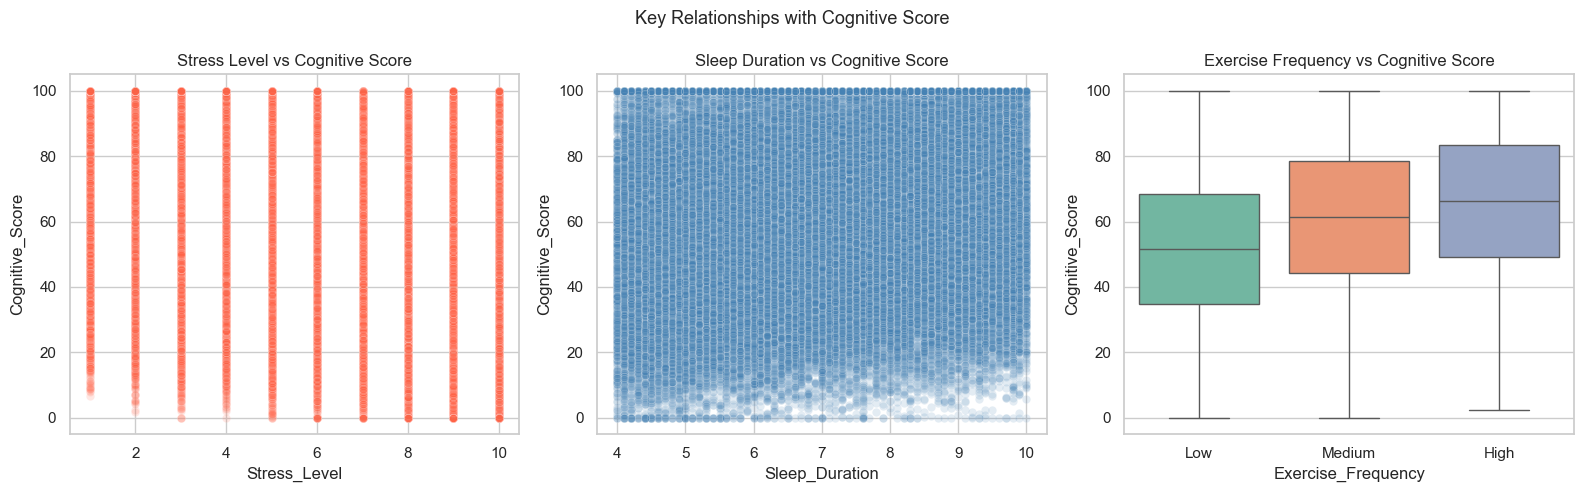

In [8]:
# The three relationships central to the cognitive tunneling thesis
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Key Relationships with Cognitive Score', fontsize=13)

sns.scatterplot(data=df_pd, x='Stress_Level',   y='Cognitive_Score', alpha=0.15, ax=axes[0], color='tomato')
axes[0].set_title('Stress Level vs Cognitive Score')

sns.scatterplot(data=df_pd, x='Sleep_Duration', y='Cognitive_Score', alpha=0.15, ax=axes[1], color='steelblue')
axes[1].set_title('Sleep Duration vs Cognitive Score')

sns.boxplot(data=df_pd, x='Exercise_Frequency', y='Cognitive_Score',
            order=['Low', 'Medium', 'High'], ax=axes[2], palette='Set2')
axes[2].set_title('Exercise Frequency vs Cognitive Score')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'key_relationships.png', dpi=150, bbox_inches='tight')
plt.show()

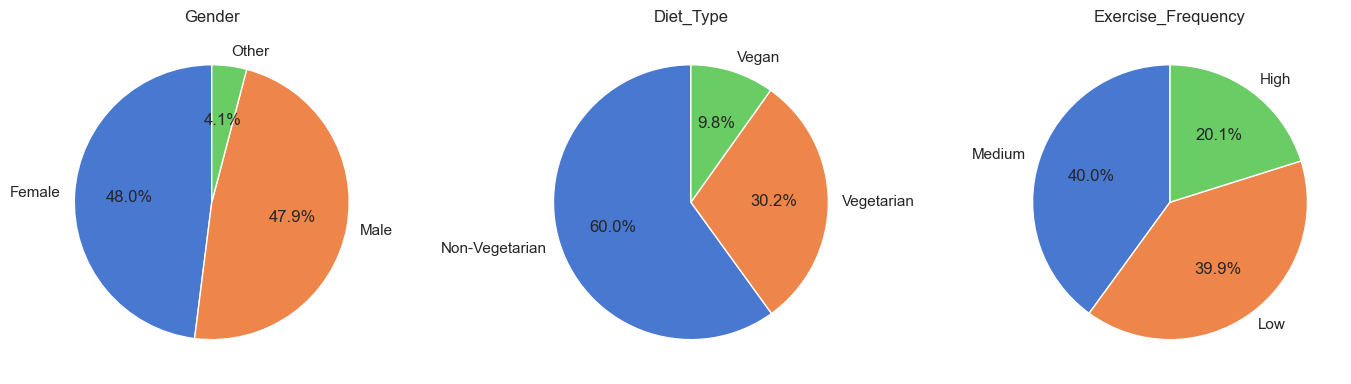

In [9]:
# Categorical feature breakdowns
CATEGORICAL = ['Gender', 'Diet_Type', 'Exercise_Frequency']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, CATEGORICAL):
    counts = df_pd[col].value_counts()
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
    ax.set_title(col)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Feature Engineering

Three interaction features grounded in the project's cognitive psychology rationale:

- **Stress × Sleep** — the antagonistic relationship driving cognitive tunneling
- **Caffeine / Sleep** — caffeine-to-recovery ratio; high values signal risk
- **Fatigue Load** — composite of stress + screen time minus sleep

In [10]:
df = df.with_columns([
    (pl.col('Stress_Level') * pl.col('Sleep_Duration')).alias('Stress_Sleep_Interaction'),
    (pl.col('Caffeine_Intake') / (pl.col('Sleep_Duration') + 1)).alias('Caffeine_Sleep_Ratio'),
    (pl.col('Stress_Level') + pl.col('Daily_Screen_Time') - pl.col('Sleep_Duration')).alias('Fatigue_Load'),
])

print("Engineered features added.")
df.select(['Stress_Sleep_Interaction', 'Caffeine_Sleep_Ratio', 'Fatigue_Load']).describe()

Engineered features added.


statistic,Stress_Sleep_Interaction,Caffeine_Sleep_Ratio,Fatigue_Load
str,f64,f64,f64
"""count""",80000.0,80000.0,80000.0
"""null_count""",0.0,0.0,0.0
"""mean""",38.510182,32.711475,4.993076
"""std""",22.798562,20.906434,4.595235
"""min""",4.0,0.0,-7.8
"""25%""",19.4,15.384615,1.8
"""50%""",36.0,31.122449,5.0
"""75%""",54.0,46.792453,8.3
"""max""",100.0,99.8,18.0


## 4. Risk Label Assignment

Cognitive risk tiers are derived from score tertiles (33rd / 67th percentile).
Data-driven thresholds are more defensible than arbitrary fixed cutoffs.

In [11]:
low_thresh  = df['Cognitive_Score'].quantile(0.33)
high_thresh = df['Cognitive_Score'].quantile(0.67)
print(f"Low  threshold (33rd pct) : {low_thresh:.2f}")
print(f"High threshold (67th pct) : {high_thresh:.2f}")

df = df.with_columns(
    pl.when(pl.col('Cognitive_Score') <= low_thresh).then(pl.lit('Low'))
      .when(pl.col('Cognitive_Score') <= high_thresh).then(pl.lit('Medium'))
      .otherwise(pl.lit('High'))
      .alias('Risk_Level')
)
print(df['Risk_Level'].value_counts())

Low  threshold (33rd pct) : 46.83
High threshold (67th pct) : 69.98
shape: (3, 2)
┌────────────┬───────┐
│ Risk_Level ┆ count │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ Medium     ┆ 27197 │
│ High       ┆ 26394 │
│ Low        ┆ 26409 │
└────────────┴───────┘


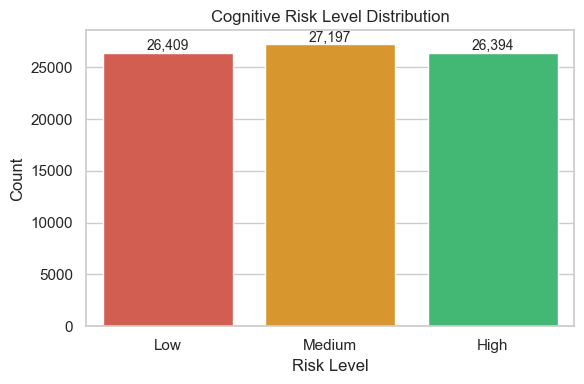

In [12]:
df_pd = df.to_pandas()
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df_pd, x='Risk_Level', order=['Low', 'Medium', 'High'],
                   palette=['#e74c3c', '#f39c12', '#2ecc71'])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.title('Cognitive Risk Level Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Preprocessing Pipeline

In [13]:
NUMERICAL_FEATURES = [
    'Age', 'Sleep_Duration', 'Stress_Level', 'Daily_Screen_Time',
    'Caffeine_Intake', 'Reaction_Time', 'Memory_Test_Score',
    'Stress_Sleep_Interaction', 'Caffeine_Sleep_Ratio', 'Fatigue_Load'
]
CATEGORICAL_FEATURES = ['Gender', 'Diet_Type', 'Exercise_Frequency']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUMERICAL_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_FEATURES)
], remainder='drop')

X = df_pd[NUMERICAL_FEATURES + CATEGORICAL_FEATURES]
preprocessor.fit(X)

joblib.dump(preprocessor, MODELS_DIR / 'preprocessor.pkl')
print(f"Preprocessor fitted and saved.")
print(f"  Numerical features  : {len(NUMERICAL_FEATURES)}")
print(f"  Categorical features: {len(CATEGORICAL_FEATURES)}")

Preprocessor fitted and saved.
  Numerical features  : 10
  Categorical features: 3


In [14]:
# Save processed dataset
df.write_csv(PROC_DATA)
print(f"Processed data saved → {PROC_DATA}")
print(f"Final shape: {df.shape}")
df.head()

Processed data saved → C:\Users\Atharv Chaudhary\PycharmProjects\AI-CIA-3\data\processed\processed_data.csv
Final shape: (80000, 17)


User_ID,Age,Gender,Sleep_Duration,Stress_Level,Diet_Type,Daily_Screen_Time,Exercise_Frequency,Caffeine_Intake,Reaction_Time,Memory_Test_Score,Cognitive_Score,AI_Predicted_Score,Stress_Sleep_Interaction,Caffeine_Sleep_Ratio,Fatigue_Load,Risk_Level
str,i64,str,f64,i64,str,f64,str,i64,f64,i64,f64,f64,f64,f64,f64,str
"""U1""",57,"""Female""",6.5,3,"""Non-Vegetarian""",6.5,"""Medium""",41,583.33,65,36.71,39.77,19.5,5.466667,3.0,"""Low"""
"""U2""",39,"""Female""",7.6,9,"""Non-Vegetarian""",10.8,"""High""",214,368.24,58,54.35,57.68,68.4,24.883721,12.2,"""Medium"""
"""U3""",26,"""Male""",8.2,6,"""Vegetarian""",5.7,"""Low""",429,445.21,49,32.57,29.54,49.2,46.630435,3.5,"""Low"""
"""U4""",32,"""Male""",7.8,9,"""Vegetarian""",8.3,"""Low""",464,286.33,94,70.15,74.59,70.2,52.727273,9.5,"""High"""
"""U5""",50,"""Male""",9.7,2,"""Non-Vegetarian""",11.3,"""Medium""",365,237.65,62,87.54,91.78,19.4,34.11215,3.6,"""High"""
